In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from datasets import load_dataset

c:\Users\User\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Loading the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

In [3]:
# Dataset Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [94]:
df_US = df[df['job_country'] == 'United States'].dropna(subset='salary_year_avg').copy()

In [97]:
job_titles = df_US['job_title_short'].value_counts().head(6).index.to_list()

In [100]:
df_jobs_top6 = df_US[df_US['job_title_short'].isin(job_titles)]

In [106]:
jobs_order = df_jobs_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

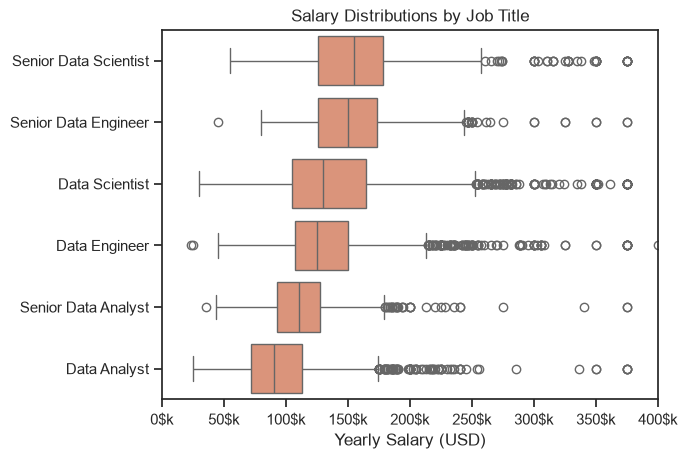

In [109]:
sns.boxplot(
        data=df_jobs_top6, 
        y='job_title_short', 
        x='salary_year_avg',
        order=jobs_order
    )
sns.set_theme(style='ticks', palette='flare')

plt.title('Salary Distributions by Job Title')
plt.ylabel('')
plt.xlabel('Yearly Salary (USD)')

from matplotlib.ticker import FuncFormatter

ax = plt.gca()
ax.set_xlim(0,400000)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:.0f}$k'))

In [119]:
df_US_DA = df_US[df_US['job_title_short'] == 'Data Analyst'].copy()
df_US_DA = df_US_DA.explode('job_skills')

In [136]:
df_top_pay = (
    df_US_DA
    .groupby('job_skills')['salary_year_avg']
    .agg(['count', 'median'])
    .sort_values(by='median', ascending=False)
)
df_top_pay = df_top_pay.head(10)
df_top_pay

,count,median
job_skills,,
dplyr,2,196250.0
bitbucket,3,189000.0
gitlab,3,186000.0
solidity,1,179000.0
hugging face,1,175000.0
couchbase,1,160515.0
ansible,1,159640.0
mxnet,2,149000.0
cassandra,6,148250.0


In [135]:
df_top_skills = (
    df_US_DA
    .groupby('job_skills')['salary_year_avg']
    .agg(['count', 'median'])
    .sort_values(by='count', ascending=False)
)
df_top_skills = df_top_skills.head(10).sort_values(by='median', ascending=False)
df_top_skills

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


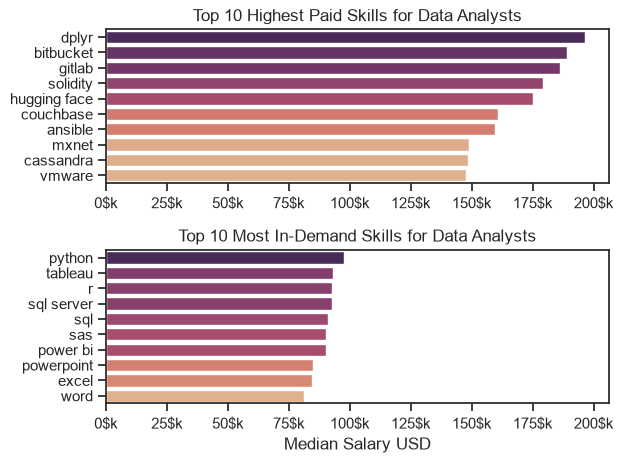

In [160]:

fig, ax = plt.subplots(2, 1)

sns.set_theme(style='ticks')

sns.barplot(data=df_top_pay, x='median', y='job_skills', ax=ax[0], hue='median', palette='flare')

ax[0].legend().remove()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:.0f}$k'))

sns.barplot(data=df_top_skills, x='median', y='job_skills', ax=ax[1], hue='median', palette='flare')
ax[1].legend().remove()
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary USD')
ax[1].set_xlim(ax[0].get_xlim()) # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:.0f}$k'))


plt.tight_layout()
plt.show()